# Ensemble Kaggle branch

In this notebook we process te image input and train an ensemble model with 
different arquitectures

In [10]:
# --- Imports & config ---
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
import timm
import os
import random
import joblib
from sklearn.model_selection import StratifiedGroupKFold
import time, torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import cv2
import albumentations as A

import sys
sys.path.append("../utils")
from utils import (create_balanced_split, 
                   ISIC_Multimodal_Dataset, 
                   get_best_metadata, 
                   MetadataProcessor,
                   AdvancedHairAugmentation, 
                   Microscope,
                   get_fold_datalodaers,
                   TrainableModule, 
                   remove_last_layer,   
                   plot_analisis,
                   plot_stats)

# configure all:
class config:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    data_dir = Path("../data")
    models_dir = Path("../models")
    utils_dir = Path("../utils")
    submission_dir = Path("../submission")
    train_meta_csv = data_dir / "train-metadata.csv"
    test_meta_csv = data_dir / "test-metadata.csv"
    train_hdf5 = data_dir / "train-image.hdf5"
    test_hdf5 = data_dir / "test-image.hdf5"
    meta_procesor = utils_dir / "metadata_processor.pkl"
    metamodel_path = utils_dir / "metamodel.plk"
    ensemble_train_csv = utils_dir / "ensemble_train.csv"
    hairs_path = utils_dir / "hairs"
    lr = 1e5
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225],
    seed = 42
    image_size = 224
    epochs = 50
    batch_size = 16
    num_imgs_epoch = 3000
    target_epoch_proportion = 0.50
    BCE_loss_pos_weight = 1
    ratio_neg_pos = 25
    val_split = 0.2             # of train
    num_folds = 5
    num_feat = 0                # 0 = use all
    fine_tuning_batch = 70      # batch to train ensemble models
    val_freq = 5                # frequency of validation analisis
    attention_dim = 256         # dimension of trained attention ensemble
    unfreeze_schedule = [
        (5, 0.2),   # in epoch 5, 20%
        (40, 0.5),  # in epoch 30, 50%
        # (65, 0.75), # in epoch 65, 75%
    ]

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(config.seed)

## Load and analyze the data

Because of the extreme class imbalance in the ISIC dataset (≈0.01% malignant vs. 99.99% benign), we apply two complementary strategies.  
First, we limit the number of benign samples by enforcing a controlled ratio of **25 benign lesions per malignant lesion** during training.  
Second, we apply an extensive yet medically appropriate **augmentation pipeline** to increase the effective diversity of malignant samples and reduce overfitting.

Below is a summary of the augmentation strategy used.

---

## Data Augmentation for Skin Lesion Classification (ISIC)

To improve the robustness of our multimodal classifier, we apply a set of **recommended and dermatology-consistent augmentations**, inspired by prior work on dermoscopic augmentation. In particular, our use of `AdvancedHairAugmentation` and `Microscope` artifacts was borrowed from the approach of GreatGameDota/SIIM-ISIC-Melanoma-Classification. :contentReference[oaicite:2]{index=2}

These transformations simulate realistic sources of variability such as camera angle, zoom, lighting, dermoscopic artifacts, and partial occlusions.

### 🔧 Summary of the Training Augmentation Pipeline

1. **Geometric Transformations (OneOf: ShiftScaleRotate / Affine / Perspective)**  
   A single transformation is chosen at random:
   - **ShiftScaleRotate**: small shifts, scaling (±15%), and rotations (±80°).  
   - **Affine (shear)**: simulates slight camera tilt.  
   - **Perspective**: mimics viewpoint variation.  
   **Purpose:** models acquisition differences across dermatoscopes while preserving lesion morphology.

2. **Horizontal & Vertical Flip (p=0.5 each)**  
   **Purpose:** lesions have no fixed orientation; flipping increases spatial variability safely.

3. **Resize to fixed resolution**  
   Ensures all images match the model input size.

4. **AdvancedHairAugmentation (p=0.5)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds realistic synthetic hairs over the image.  
   **Purpose:** increases robustness to one of the most common dermoscopic artifacts (hairs).

5. **RandomBrightnessContrast**  
   **Purpose:** simulates differences in lighting conditions, camera exposure, and skin tone variability.

6. **CoarseDropout (1–8 holes, up to 25% area)**  
   Randomly removes patches of the image.  
   **Purpose:** simulates partial occlusions (e.g. ruler marks, bubbles, ink, gel, hair clusters) and improves robustness.

7. **Microscope Effect (p=0.1)** — *inspired by* GreatGameDota/SIIM-ISIC solution  
   Adds subtle lens or artefact-like distortions to simulate variability across dermatoscopic devices.  
   **Purpose:** increases generalization frente a variaciones de dispositivo o iluminación.

8. **Normalize (mean=0, std=1)**  
   Standard normalization for stable training.

### Validation Transformations

- **Resize** to input size  
- **Normalize** (mean=0, std=1)  

No augmentation is applied at validation time in order to evaluate performance on unaltered data.

---

## Scientific Support

These transformations are compatible with recommended augmentation practices in biomedical imaging. In particular, hair-artifact simulation and occlusion–robust augmentation han sido utilizados con éxito en pipelines para clasificación de melanoma (ver GreatGameDota/SIIM-ISIC-Melanoma-Classification).  
Además, trabajos como Towards Better Dermoscopic Image Feature Representation Learning for Melanoma Classification destacan que la presencia de artefactos (pelo, marcas, iluminación variable) representa un reto real en imágenes dermatoscópicas, y que estrategias como augmentación con oclusiones o ruido son útiles para mejorar la generalización. :contentReference[oaicite:4]{index=4}

---

Together, this augmentation pipeline improves generalization, reduces overfitting, and compensates for the scarcity of malignant samples in the dataset.


In [11]:
train_transform = A.Compose([
    A.OneOf([
        A.ShiftScaleRotate(scale_limit=0.15, rotate_limit=80, shift_limit=0.1,
                           border_mode=cv2.BORDER_REPLICATE, p=0.5),
        A.Affine(shear=20, p=0.5),  # 'mode' eliminado
        A.Perspective(p=0.5),
    ], p=0.5),

    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(config.image_size, config.image_size),

    AdvancedHairAugmentation(hairs=10, hairs_folder=config.hairs_path, p=0.5),
    A.RandomBrightnessContrast(),

    # CoarseDropout nuevo: usa num_holes, max_height, max_width
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(0.1, 0.25),
                    hole_width_range=(0.1, 0.25), 
                    fill=0, p=0.3),
    Microscope(p=0.1),

    # Normalize nuevo: no usar always_apply
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

val_transform = A.Compose([
    A.Resize(config.image_size, config.image_size),
    A.Normalize(mean=(0.0, 0.0, 0.0), std=(1.0, 1.0, 1.0))
])

/home/pawn/anaconda3/envs/aprendizaje/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:436: UserWarning: Argument(s) 'always_apply' are not valid for transform BasicTransform
  super().__init__(always_apply=always_apply, p=p)


## Dataset analisis

In [12]:
# 1º Create a split of train and validation balanced
# we dont need all the images
train_df, val_df, df_balanced = create_balanced_split(
    config.train_meta_csv,
    neg_multiplier=config.ratio_neg_pos,      # conservative ratio of 25:1 
    val_frac=config.val_split            # split a 20% of train to validation
)

test_df = pd.read_csv(config.test_meta_csv, low_memory=False)

# 2º Run the metadata processor
if Path(config.meta_procesor).exists():
    metadata_processor =joblib.load(config.meta_procesor)
else:
    best_features = get_best_metadata(train_df, test_df, num_feat=config.num_feat, verbose=True)
    metadata_processor = MetadataProcessor(best_features)
    metadata_processor.fit(pd.read_csv(config.train_meta_csv))
    joblib.dump(metadata_processor, config.meta_procesor)



train_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=train_df,
    image_transform=train_transform,
    metadata_processor=metadata_processor
)

val_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.train_hdf5,
    metadata_df=val_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

test_dataset = ISIC_Multimodal_Dataset(
    hdf5_path=config.test_hdf5,
    metadata_df=test_df,
    image_transform=val_transform,
    metadata_processor=metadata_processor
)

/home/pawn/Desktop/deep_learning/ISIC_DL/src/../utils/utils.py:143: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(metadataCSV_path)


Positives: 343
Negatives available: 400616
Negatives to sample: 8575

Balanced dataset size: 8918
target
0    8575
1     343
Name: count, dtype: int64


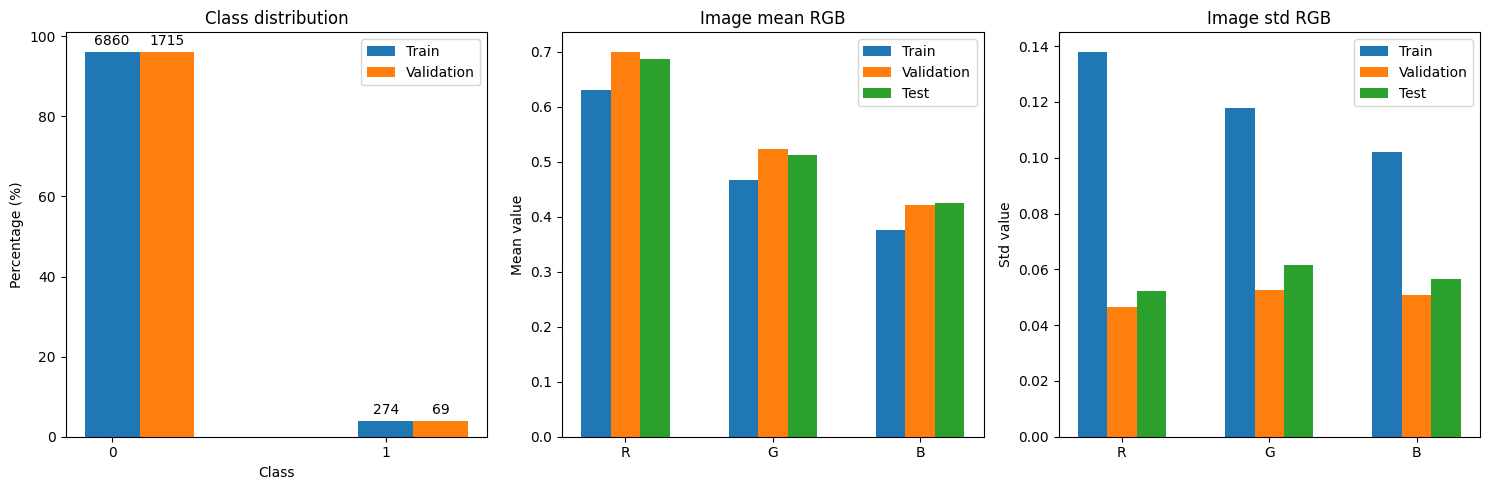

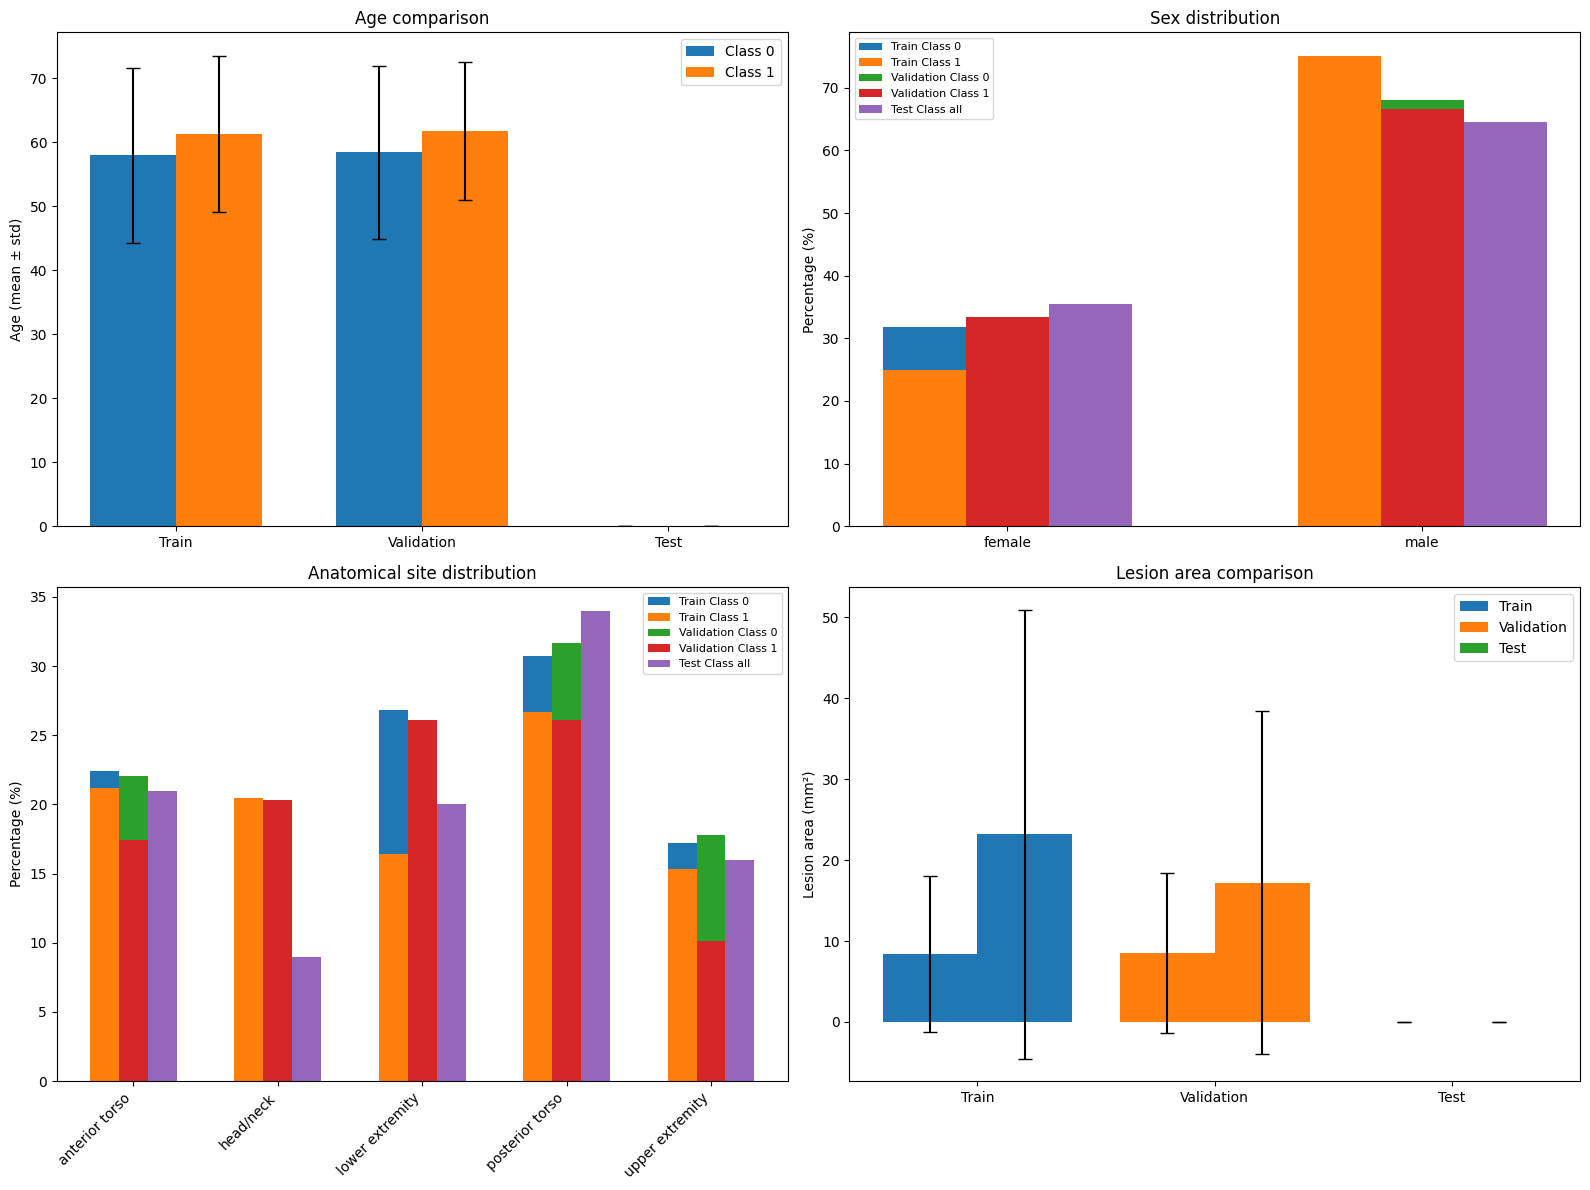

In [13]:
train_stats = train_dataset.get_dataset_stats(sample_size=300)
val_stats   = val_dataset.get_dataset_stats(sample_size=300)
test_stats  = test_dataset.get_dataset_stats(sample_size=300)
stats_list = [train_stats, val_stats, test_stats]

# clean dataset variables
train_dataset = None
val_dataset = None

# Now we compare the analisis of the splits
plot_stats(stats_list)

## DataLoaders with KFolds and Weighted sampler

We calculate the **ratio of the weighted sampler** using the formula:
$$
w_{c1}=\frac{p_{target}}{1-p_{target}}\frac{n_{c1}}{n_{c2}}
$$
so in the example we want $ p_{target} = 0.25 $
$$
w_{c1}=\frac{0.25}{0.75}\frac{20}{1}
$$

For the weights of the loss functions is as follows:
$$
pos_w=\frac{1-p_{posImg}}{p_{posImg}}
$$

In [14]:
kfold = StratifiedGroupKFold(
    n_splits=config.num_folds,
    shuffle=True,
    random_state=config.seed
)

# loaders 
traink_df = []
valk_df = []

fold_stats = []

for k, (train_idx, val_idx) in enumerate(
    kfold.split(train_df, train_df["target"], train_df["patient_id"])):

    train_spl = train_df.iloc[train_idx]
    val_spl = train_df.iloc[val_idx]

    train_counts = train_spl["target"].value_counts().reindex([0,1], fill_value=0)
    val_counts   = val_spl["target"].value_counts().reindex([0,1], fill_value=0)

    fold_stats.append({
        "fold": k,
        "train_total": len(train_spl),
        "tr_class_0": train_counts[0],
        "tr_class_1": train_counts[1],
        "tr_class1_%": train_counts[1] / len(train_spl),

        "val_total": len(val_spl),
        "val_class_0": val_counts[0],
        "val_class_1": val_counts[1],
        "val_class1_%": val_counts[1] / len(val_spl),
    })

    traink_df.append(train_spl)
    valk_df.append(val_spl)

# we only need test loader for kaggle submission
test_loader = DataLoader(
    test_dataset,
    batch_size=config.batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True if config.device == 'cuda' else False
)

print("📦 Multimodal data loaders created with balanced sampling!")
fold_stats_df = pd.DataFrame(fold_stats)

print("\n📊 Distribution for each fold:\n")
print(fold_stats_df.to_string(index=False))


📦 Multimodal data loaders created with balanced sampling!

📊 Distribution for each fold:

 fold  train_total  tr_class_0  tr_class_1  tr_class1_%  val_total  val_class_0  val_class_1  val_class1_%
    0         5697        5471         226     0.039670       1437         1389           48      0.033403
    1         5702        5474         228     0.039986       1432         1386           46      0.032123
    2         5837        5625         212     0.036320       1297         1235           62      0.047803
    3         5664        5447         217     0.038312       1470         1413           57      0.038776
    4         5636        5423         213     0.037793       1498         1437           61      0.040721


# Backbone

In [15]:
class AttentionFusion(nn.Module):
    """
    Fusiona img_emb y meta_emb usando Multi-Head Attention real.
    Produce una predicción escalar (1 dimensión).
    """
    def __init__(self, dim, num_heads=4, num_classes=1):
        super().__init__()

        # Multi-Head Attention (Transformer) para fusionar ambos tokens
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=False)

        # Proyección del token fusionado
        self.fusion_proj = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(dim // 2, dim // 4),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        # Predicción escalar final
        self.out = nn.Linear(dim // 4, num_classes)

    def forward(self, img_emb, meta_emb):
        """
        img_emb:  (batch, dim)
        meta_emb: (batch, dim)
        returns: (batch, 1)
        """

        # Construimos tokens → secuencia de longitud 2
        tokens = torch.stack([img_emb, meta_emb], dim=0)  
        # tokens shape: (2, batch, dim)

        # Self-attention sobre los dos tokens
        attn_out, _ = self.attn(tokens, tokens, tokens)
        # attn_out shape: (2, batch, dim)

        # Fusion: agregamos ambos tokens
        fused = attn_out.mean(dim=0)  # (batch, dim)

        # Pasamos por MLP
        fused = self.fusion_proj(fused)

        # Predicción escalar
        pred = self.out(fused)

        return pred
    
class EmbeddingHead(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
        nn.Flatten(),
        nn.Dropout(0.4),
        nn.Linear(input_dim, emb_dim),
        nn.BatchNorm1d(emb_dim),
        nn.GELU()
        )
    
    def forward(self, x):
        return self.net(x)

class MetaEncoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim=1024):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.BatchNorm1d(hidden_dim//2),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_dim//2, emb_dim)
        )
    def forward(self, x):
        return self.net(x)

class PretrainedClassifier(nn.Module):
    def __init__(self, device, model_name, model_origin, meta_dim,
                 num_classes=1, hidden_dim = 512):
        super().__init__()

        self.hidden_dim = hidden_dim

        # ----- Backbone for the image ------
        if model_origin == ".pt":
            self.backbone = torch.load(model_name)
            # change last layer
            self.backbone = remove_last_layer(self.backbone)

        elif model_origin == "timm":
            self.backbone = timm.create_model(
                model_name,
                pretrained=True,
                global_pool='avg',
                num_classes=0  # don't use the original detection head
            )

        # add a trainable head to the backbone
        self.backbone.to(device)
        self.device = device
        with torch.no_grad():
            dummy_img = torch.zeros(1, 3, 224, 224).to(device)
            img_feat = self.backbone(dummy_img)
        self.img_dim = img_feat.shape[1]

        # freeze the backbone
        for p in self.backbone.parameters():
            p.requires_grad = False

        self.backbone_head = EmbeddingHead(self.img_dim, 
                                          self.hidden_dim//2).to(device)
        
        # ------ Metadata Model -------
        self.metadata_encoder = MetaEncoder(meta_dim, emb_dim=self.hidden_dim//2).to(device)

        # ------ Fusion with attention ------
        self.attention_fusion = AttentionFusion(dim=self.hidden_dim//2, 
                                                num_heads=4,
                                                num_classes=num_classes
                                                ).to(device)


    def forward(self, images, metadata):
        # ---- Image embedding ----
        backbone_img = self.backbone(images)
        img_emb = self.backbone_head(backbone_img)

        # ---- Metadata embedding ---
        meta_emb = self.metadata_encoder(metadata)

        #----- Attention fusion -----
        out = self.attention_fusion(img_emb, meta_emb)
        return out

class PretrainedClassifierExtended(PretrainedClassifier, TrainableModule):
    def __init__(self, device, model_name, model_origin, unfreeze_scheduler, meta_dim,
                 lr, criterion, val_freq=5, patience=5, min_delta=0.01):
        PretrainedClassifier.__init__(self, device, model_name, model_origin, meta_dim)
        TrainableModule.__init__(self, criterion, device, patience, min_delta)

        self.name = model_name
        self.unfreeze_schedule = unfreeze_scheduler
        self.model_origin = model_origin
        self.val_freq = val_freq    # freq of validation metrics
        self.lr=lr
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "val_auc": []
        }

    def fit(self, train_loader, val_loader=None, epochs=10):
        print(f"----------------------------------------")
        print(f"       Training {self.name}")
        print(f"----------------------------------------")

        for epoch in range(1, epochs+1):
            torch.cuda.empty_cache()
            start = time.time()
            print(f"Epoch {epoch}/{epochs}: ", end="")

            for e, pct in self.unfreeze_schedule:
                if epoch == e:
                    self.unfreeze_backbone_layers(pct)
                    print(f"Descongelando {pct*100:.0f}% del backbone en epoch {epoch}")

            train_loss, per_pos = self._train_epoch(train_loader)
            self.history["train_loss"].append(train_loss)
            print(f"Train loss: {train_loss:.4f} || percentaje pos in epoch: {per_pos:.3f}%")

            if val_loader and epoch%self.val_freq==0:
                val_loss, val_auc = self._validate(val_loader)
                self.history["val_loss"].append(val_loss)
                self.history["val_auc"].append(val_auc)
                print(f"Val Loss: {val_loss:.4f} | AUC: {val_auc:.4f}", end="")
            
            # 🧹 Clean epoch for VRAM
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

            
            print(f" in {time.time() - start:.2f}s")

    def unfreeze_backbone_layers(self, percent=0.2):
        layers = list(self.backbone.parameters())
        n_total = len(layers)
        n_unfreeze = int(n_total * percent)

        # unfreeze the last layers
        for p in layers[-n_unfreeze:]:
            p.requires_grad = True
    
    def load(self, path):
        state = torch.load(path, map_location=self.device, weights_only=True)
        self.load_state_dict(state)
        self.to(self.device)

### Train the mix models

📂 efficientnet_b0_f0 loaded from memory


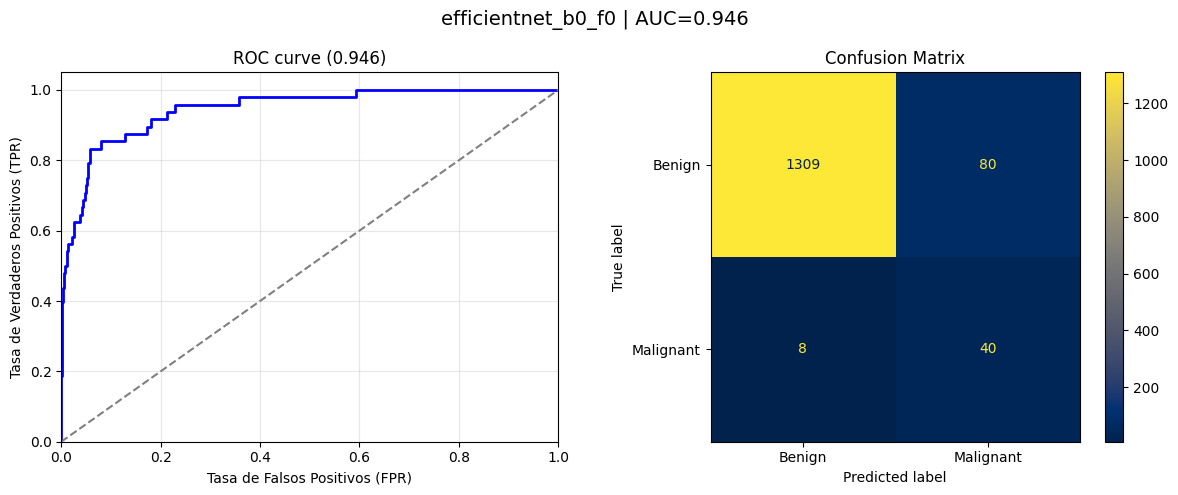

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 10.68it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f1 loaded from memory


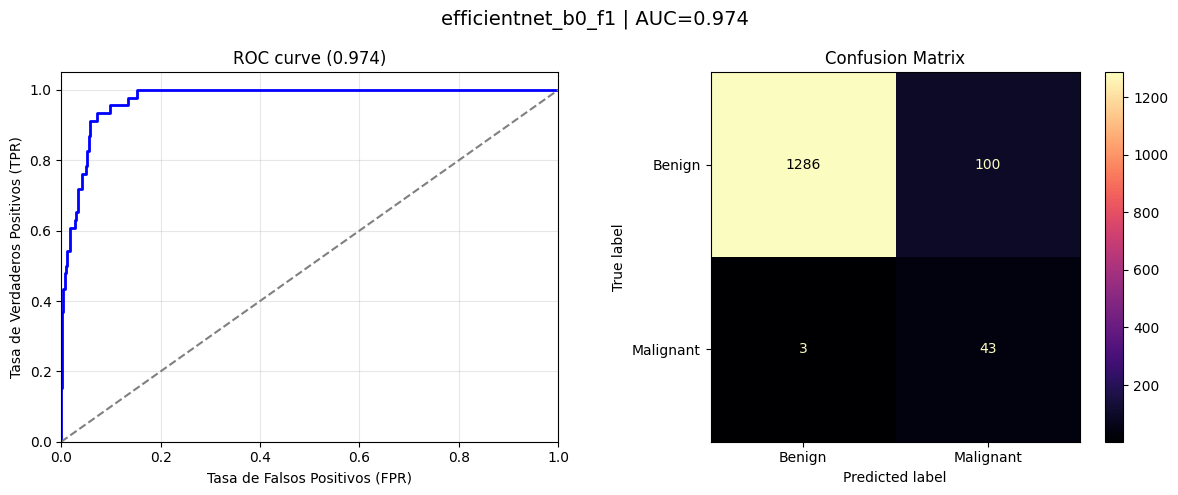

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 10.71it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f2 loaded from memory


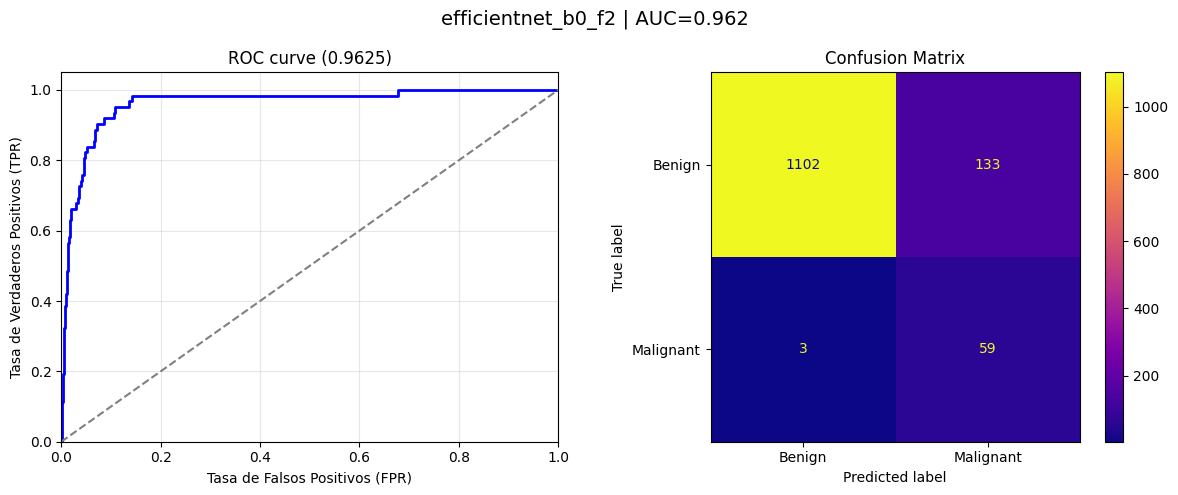

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 16.37it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f3 loaded from memory


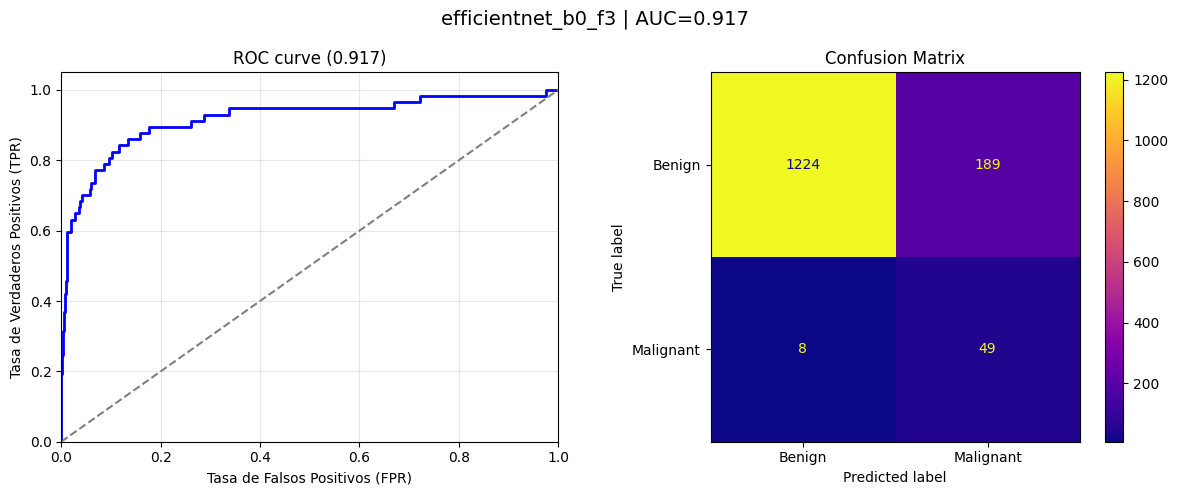

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 16.38it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 efficientnet_b0_f4 loaded from memory


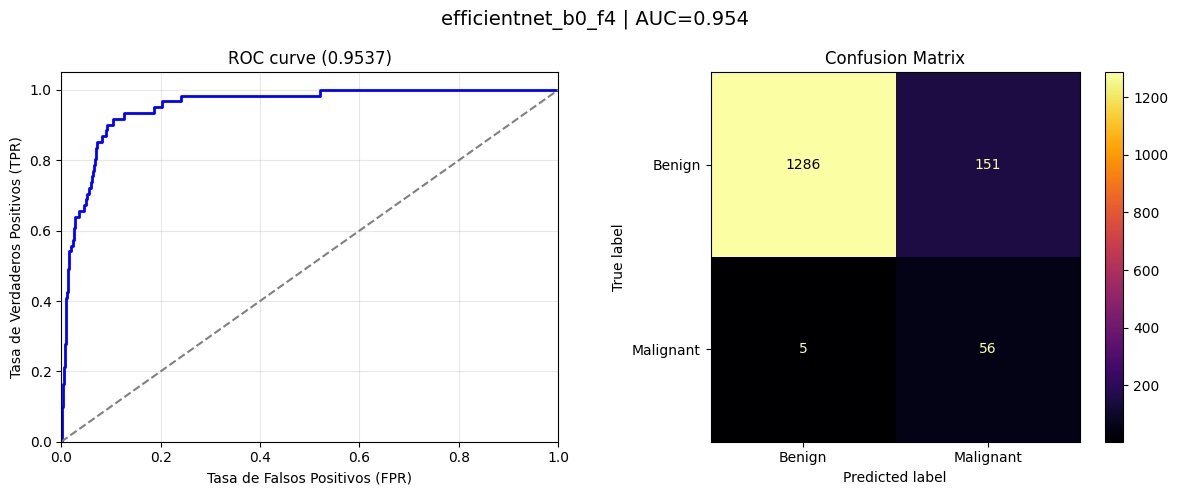

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 14.84it/s]


Saved submission with 100 rows to ../submission/efficientnet_b0.csv
📂 densenet121_f0 loaded from memory


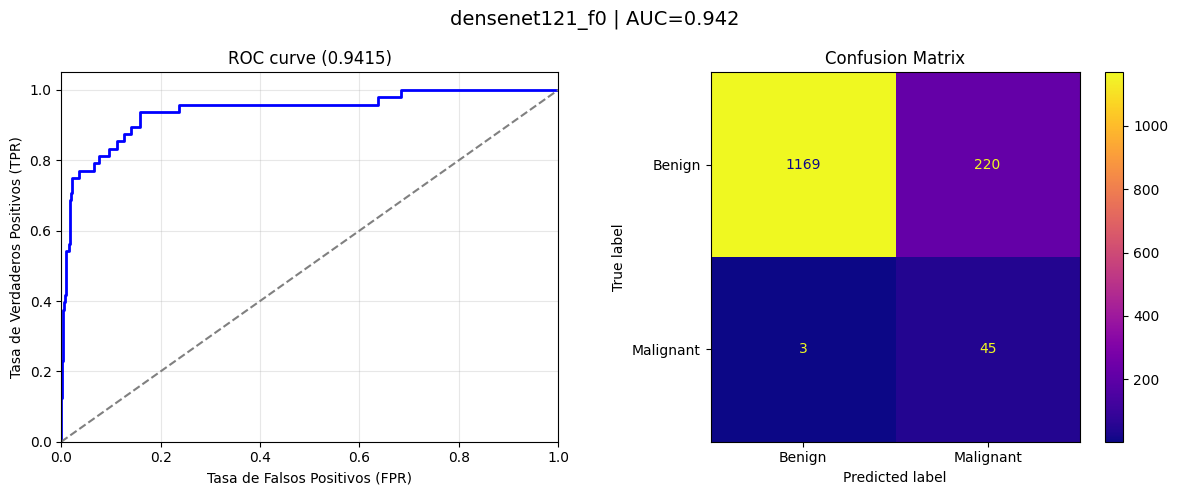

Inference on Test: 100%|██████████| 7/7 [00:00<00:00, 11.54it/s]


Saved submission with 100 rows to ../submission/densenet121.csv
📂 densenet121_f1 loaded from memory


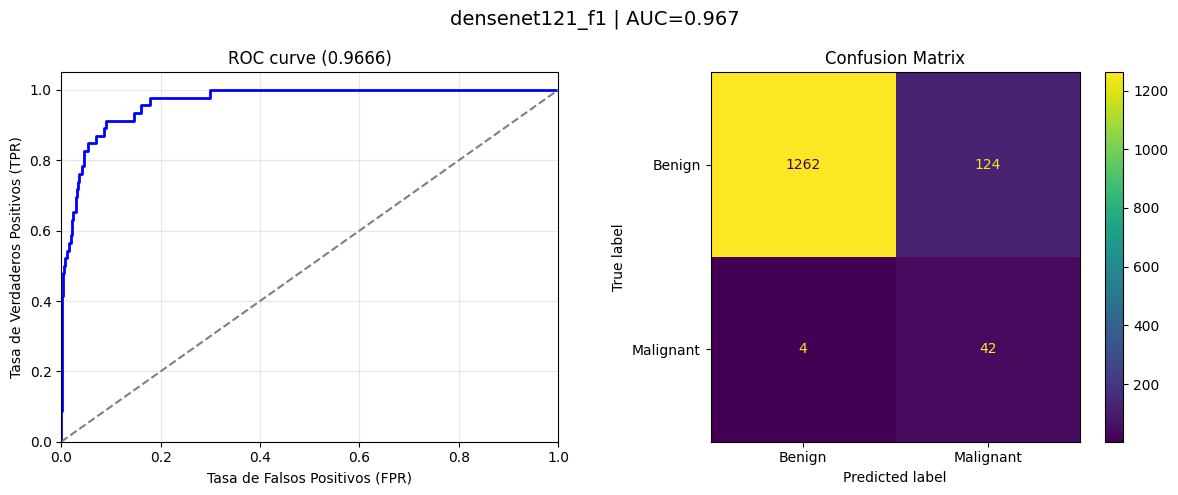

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  8.45it/s]


Saved submission with 100 rows to ../submission/densenet121.csv
📂 densenet121_f2 loaded from memory


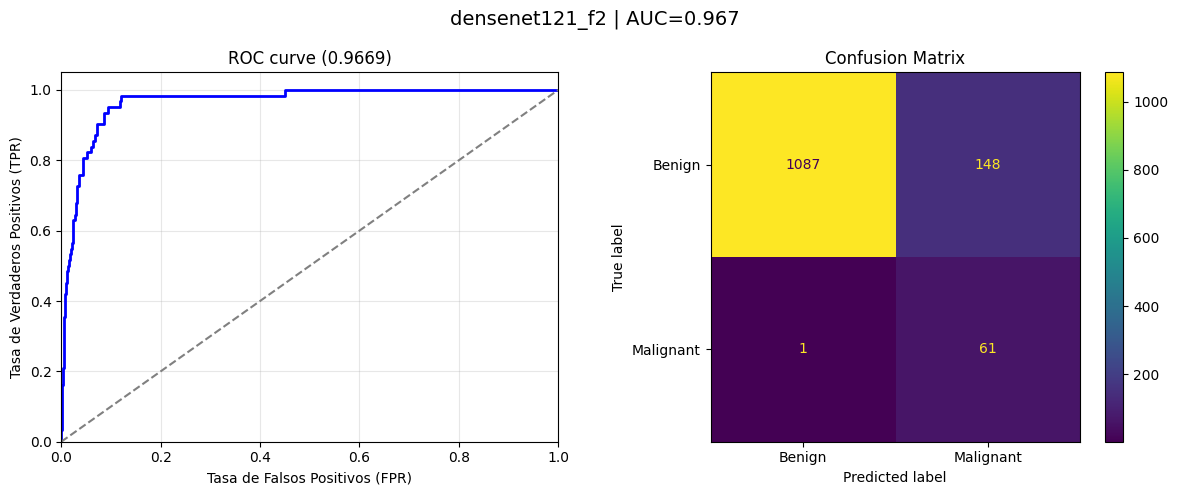

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  8.50it/s]


Saved submission with 100 rows to ../submission/densenet121.csv
📂 densenet121_f3 loaded from memory


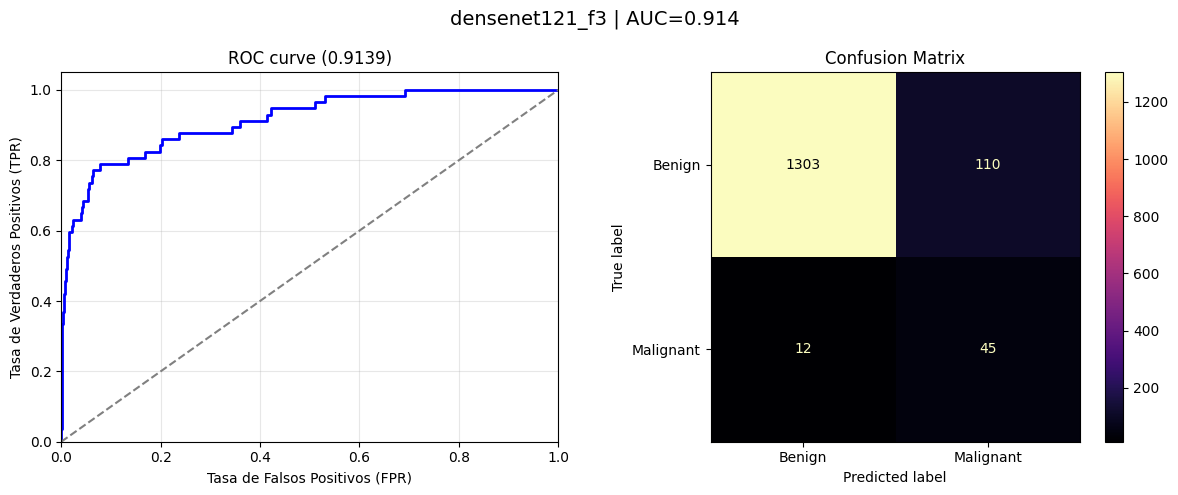

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  9.06it/s]


Saved submission with 100 rows to ../submission/densenet121.csv
📂 densenet121_f4 loaded from memory


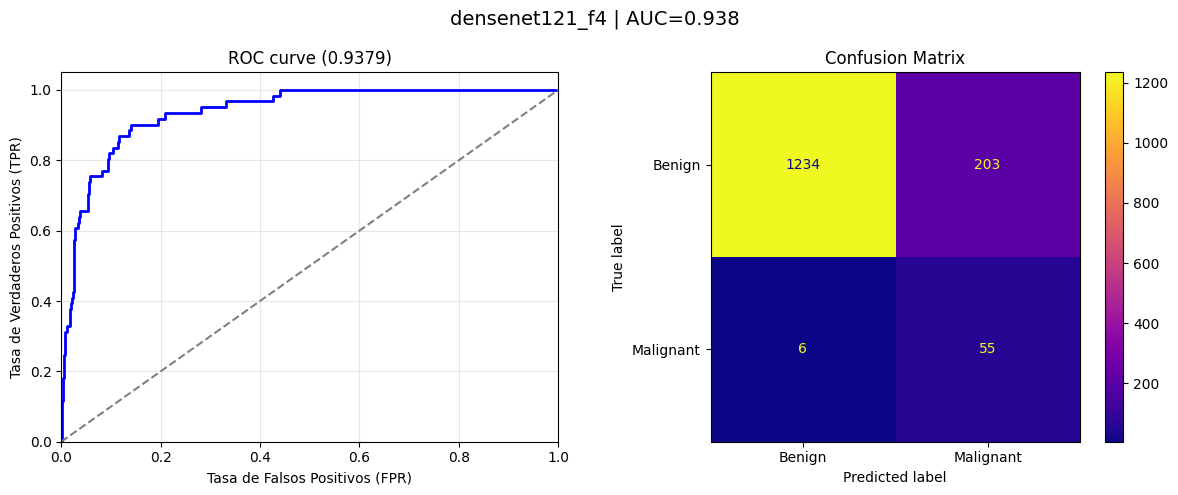

Inference on Test: 100%|██████████| 7/7 [00:00<00:00,  8.93it/s]

Saved submission with 100 rows to ../submission/densenet121.csv
💪 Ensemble weights:
	efficientnet_b0	9.98%
	efficientnet_b0	10.27%
	efficientnet_b0	10.15%
	efficientnet_b0	9.67%
	efficientnet_b0	10.06%
	densenet121	9.93%
	densenet121	10.20%
	densenet121	10.20%
	densenet121	9.64%
	densenet121	9.89%


In [19]:
# Number of features coming from metadata
num_metadata_features = metadata_processor.transform(test_df).shape[1]

# -------------------------------------------------------------------------------
# 1º Define loss and model list
# -------------------------------------------------------------------------------
pos_weights = torch.tensor(config.BCE_loss_pos_weight).to(config.device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

# model names
# ["efficient_net_f0", "efficient_net_f1", "efficient_net_f2", "efficient_net_f3", "efficient_net_f4"]
model_paths = ["efficientnet_b0", "efficientnet_b0", "efficientnet_b0", 
               "efficientnet_b0", "efficientnet_b0", 
               "densenet121", "densenet121", "densenet121", 
               "densenet121", "densenet121"]
model_orig = ["timm", "timm", "timm", "timm", "timm",
              "timm", "timm", "timm", "timm", "timm"]
model_types = ["mix", "mix", "mix", "mix", "mix",
               "mix", "mix", "mix", "mix", "mix",]

model_list = []     # for ensemble
oof_weights = []    # weights of each model based on oof predictions

# -------------------------------------------------------------------------------
# 2º Train / load ensemble models
# -------------------------------------------------------------------------------
for i, (model_name, model_orig) in enumerate(zip(model_paths, model_orig)):

    # ------- Select the fold   ---------
    fold_idx = i % config.num_folds
    train_loader, val_loader = get_fold_datalodaers(
        train_df=traink_df[fold_idx],
        validation_df=valk_df[fold_idx], 
        train_hdf5=config.train_hdf5, 
        train_transform=train_transform,
        validation_transform=val_transform, 
        metadata_processor=metadata_processor, 
        c1_prop=config.target_epoch_proportion,                 
        num_img_epoch=config.num_imgs_epoch, 
        batch_size=config.fine_tuning_batch, 
        device=config.device)

    model_name_fold = f"{model_name}_f{fold_idx}"
    save_path = f"{config.models_dir}/{model_name_fold}.pt"

    if model_name_fold + ".pt" not in os.listdir(config.models_dir):
        print(f"\n⏳ Training {model_name_fold} ...")

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq)

        model.fit(train_loader, val_loader, epochs=config.fine_tuning_batch)
        model.save(save_path)

    else:

        model = PretrainedClassifierExtended(
            model_name=model_name,
            model_origin=model_orig,
            meta_dim=num_metadata_features,
            unfreeze_scheduler=config.unfreeze_schedule,
            lr=config.lr,
            criterion=criterion,
            device=config.device,
            patience=config.fine_tuning_batch,
            val_freq=config.val_freq
        )
        model.load(save_path)
        print(f"📂 {model_name_fold} loaded from memory")

    # analize model and get its submission file
    labels, probs = model.pred_probs(val_loader)
    plot_analisis(model.name, labels, probs, fold_idx)
    oof_weights.append(roc_auc_score(labels, probs))

    config.submission_dir.mkdir(parents=True, exist_ok=True)
    model.submit_kaggle(test_loader, 
                        submission_file=f"{config.submission_dir}/{model_name}.csv")
    model_list.append(model)

# promediate the weights based in thir roc auc
oof_weights = np.array(oof_weights)
oof_weights = oof_weights / oof_weights.sum()
print("💪 Ensemble weights:")
for w, name in zip(oof_weights, model_paths):
    print(f"\t{name}\t{w*100:.2f}%")

### Now we use the trained models in an ensemble to give more generalization power

### Voting ensemble

In [17]:
from tqdm import tqdm

class SoftVotingEnsemble(nn.Module):
    def __init__(self, models, model_name, device, weights=None):
        """
        models: lista de modelos PyTorch ya entrenados
        device: 'cuda' o 'cpu'
        weights: lista de pesos para cada modelo (opcional)
        """
        super().__init__()
        self.device = device
        self.name = model_name
        self.models = nn.ModuleList(models)
        self.num_models = len(models)
        
        # Freeze the models
        for m in self.models:
            m.eval()
            for p in m.parameters():
                p.requires_grad = False
            m.to(device)
        
        # Pesos
        if weights is None:
            self.weights = torch.ones(self.num_models) / self.num_models
        else:
            w = torch.tensor(weights, dtype=torch.float32)
            self.weights = w / w.sum()
        
        self.weights = self.weights.to(device)
    
    def forward(self, images, metadata=None):
        """
        Forward sobre un batch
        images: Tensor (B, C, H, W)
        metadata: Tensor opcional para modelos que lo usen
        """
        preds = []
        for m in self.models:
            if metadata is not None:
                logits = m(images, metadata)
            else:
                logits = m(images)
            preds.append(logits.view(-1, 1))  # asegurarse shape (B,1)
        
        preds = torch.cat(preds, dim=1)  # (B, num_models)
        final = (preds * self.weights).sum(dim=1, keepdim=True)  # promedio ponderado
        return final  # logits

    def pred_probs(self, loader):
        """
        Return labels and predicted probabilities for a given dataloader.

        Parameters
        ----------
        loader : DataLoader
            PyTorch DataLoader for validation/test.

        Returns
        -------
        labels : np.ndarray
            Ground truth labels.
        probs : np.ndarray
            Predicted probabilities (sigmoid applied).
        """
        self.eval()
        labels_list = []
        probs_list = []

        with torch.no_grad():
            for images, metadata, labels, _ in loader:
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)
                labels = labels.float()

                logits = self(images, metadata).squeeze(dim=1)
                probs = torch.sigmoid(logits)

                labels_list.append(labels.cpu())
                probs_list.append(probs.cpu())

        labels = torch.cat(labels_list).numpy()
        probs = torch.cat(probs_list).numpy()

        return labels, probs
    
    def submit_kaggle(self, test_loader, submission_file="submission.csv"):
        """
        Generate Kaggle submission CSV using ensemble predictions.

        Parameters:
        -----------
        test_loader : DataLoader
            Test dataset loader. Should yield (images, metadata, isic_ids) or (images, isic_ids)
        submission_file : str
            Output CSV filename

        Returns:
        --------
        submission_df : pd.DataFrame
            DataFrame containing 'isic_id' and 'target' columns
        """
        self.eval()
        predictions = []

        with torch.no_grad():
            for images, metadata, isic_ids in tqdm(test_loader, desc="Inference on Test"):
                images = images.to(self.device, non_blocking=True)
                metadata = metadata.to(self.device, non_blocking=True)

                logits = self(images, metadata).squeeze()
                probs = torch.sigmoid(logits)
                
                probs = probs.cpu().numpy()
                for isic_id, p in zip(isic_ids, probs):
                    predictions.append({"isic_id": isic_id, "target": float(p)})

        submission_df = pd.DataFrame(predictions)
        submission_df = submission_df.sort_values(by="isic_id").reset_index(drop=True)
        submission_df.to_csv(submission_file, index=False)

        print(f"Saved submission with {len(submission_df)} rows to {submission_file}")


# Train Ensemble


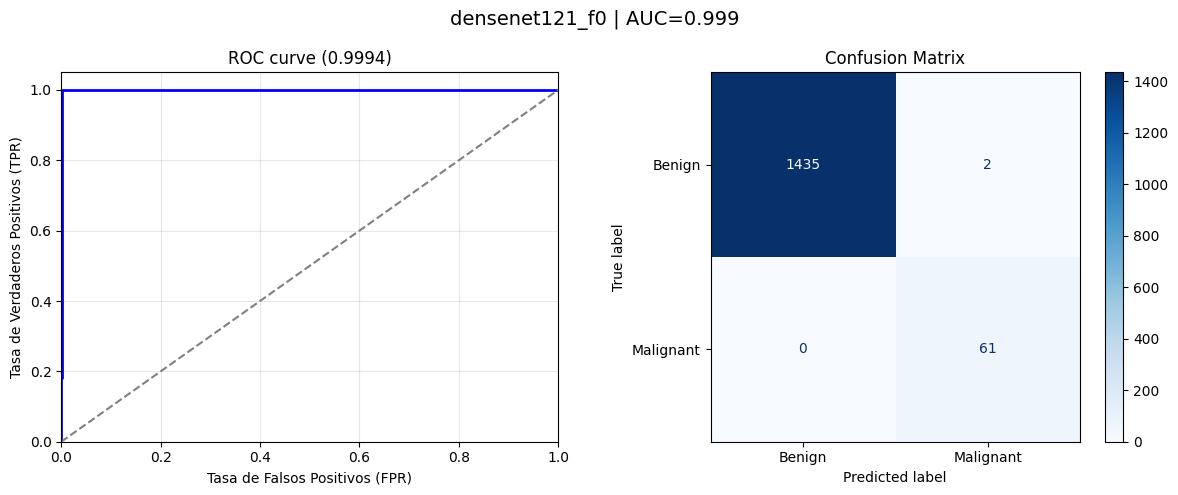

Inference on Test: 100%|██████████| 7/7 [00:02<00:00,  2.91it/s]

Saved submission with 100 rows to ../submission/Weighted_Ensemble.csv


In [18]:
ensemble = SoftVotingEnsemble(model_list, "Weighted_Ensemble", 
                              weights=oof_weights, device=config.device)

labels, probs = ensemble.pred_probs(val_loader)
plot_analisis(model_name, labels, probs)

ensemble.submit_kaggle(test_loader, 
                            submission_file=f"{config.submission_dir}/Weighted_Ensemble.csv")